In [4]:
import pandas as pd

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load Data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Baseline Gaussian Naive Bayes
gnb = GaussianNB()

# Train Model
gnb.fit(X_train, y_train)

# Predictions
train_pred = gnb.predict(X_train)
test_pred = gnb.predict(X_test)

# In-Sample Performance
print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train, train_pred))
print("Precision:", precision_score(y_train, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, train_pred, average='weighted'))

# Out-of-Sample Performance
print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 0.6339529669237844
Precision: 0.8330451656269467
Recall   : 0.6339529669237844
F1 Score : 0.6365931546196595

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.3378414568826995
Precision: 0.6591062273856666
Recall   : 0.3378414568826995
F1 Score : 0.38535501725316534

Classification Report
              precision    recall  f1-score   support

           0       0.17      0.94      0.28      1525
           1       0.00      0.00      0.00      1667
           2       0.00      0.00      0.00      1040
           3       0.07      0.49      0.12      1012
           4       0.50      0.51      0.51      4827
           5       0.00      0.00      0.00      1388
           6       0.00      0.00      0.00      1231
           7       0.99      0.33      0.50     17182

    accuracy                           0.34     29872
   macro avg       0.22      0.28      0.18     29872
weighted avg       0.66      0.34      0.39     29872



C:\Users\bavya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bavya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bavya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bavya\anaconda3\Lib

In [2]:
import numpy as np
import pandas as pd

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# 80-20 Split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

# Model
gnb = GaussianNB()

# Hyperparameter Grid
param_grid = {
    'var_smoothing': np.logspace(-12, -6, 7)
}

# Grid Search
grid_search = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_sub, y_train_sub)

print("Best Parameters:")
print(grid_search.best_params_)

best_gnb = grid_search.best_estimator_

# Predictions
train_pred = best_gnb.predict(X_train_sub)
val_pred = best_gnb.predict(X_val)
test_pred = best_gnb.predict(X_test)

# Validation Performance
print("\nVALIDATION PERFORMANCE")
print("Accuracy :", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred, average='weighted'))
print("Recall   :", recall_score(y_val, val_pred, average='weighted'))
print("F1 Score :", f1_score(y_val, val_pred, average='weighted'))

# Test Performance
print("\nOUT-OF-SAMPLE PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best Parameters:
{'var_smoothing': np.float64(1e-06)}

VALIDATION PERFORMANCE
Accuracy : 0.6576597744360902
Precision: 0.8319365318468462
Recall   : 0.6576597744360902
F1 Score : 0.6597051071139918

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.33278655597214785
Precision: 0.6575282458362997
Recall   : 0.33278655597214785
F1 Score : 0.39472731782101794


C:\Users\bavya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [5]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Baseline NB", "Tuned NB"],
    "Accuracy": [
        accuracy_score(y_test, gnb.predict(X_test)),
        accuracy_score(y_test, best_gnb.predict(X_test))
    ],
    "Precision": [
        precision_score(y_test, gnb.predict(X_test), average='weighted'),
        precision_score(y_test, best_gnb.predict(X_test), average='weighted')
    ],
    "Recall": [
        recall_score(y_test, gnb.predict(X_test), average='weighted'),
        recall_score(y_test, best_gnb.predict(X_test), average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, gnb.predict(X_test), average='weighted'),
        f1_score(y_test, best_gnb.predict(X_test), average='weighted')
    ]
})

print(comparison.round(4))

C:\Users\bavya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bavya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


         Model  Accuracy  Precision  Recall  F1 Score
0  Baseline NB    0.3378     0.6591  0.3378    0.3854
1     Tuned NB    0.3328     0.6575  0.3328    0.3947


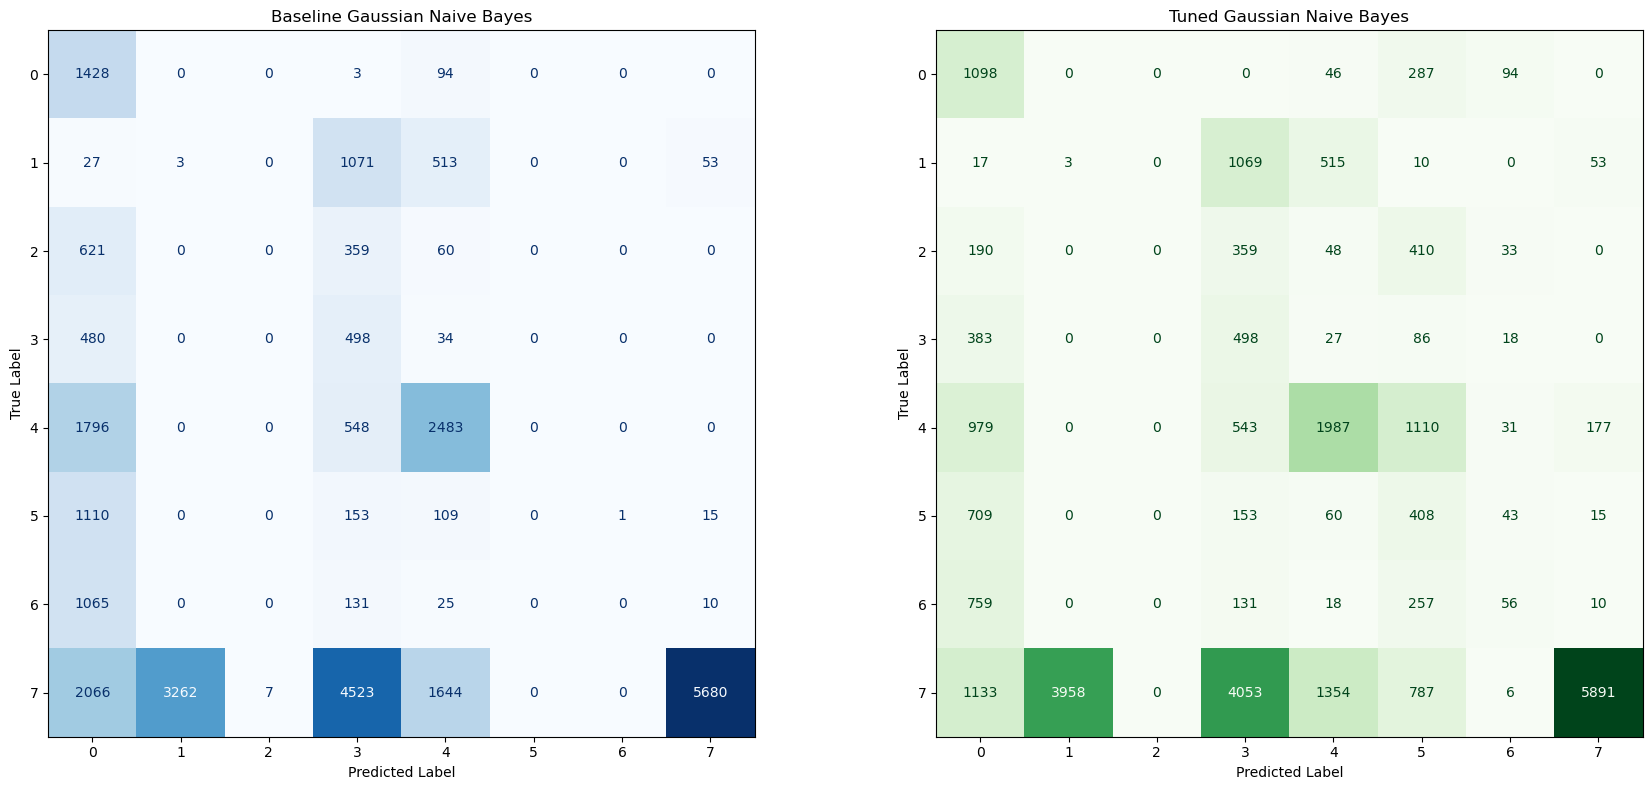

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
baseline_pred = gnb.predict(X_test)
tuned_pred = best_gnb.predict(X_test)

# Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_pred)
cm_tuned = confusion_matrix(y_test, tuned_pred)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Baseline Gaussian Naive Bayes
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=gnb.classes_
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format='d'
)

axes[0].set_title("Baseline Gaussian Naive Bayes")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Tuned Gaussian Naive Bayes
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_gnb.classes_
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format='d'
)

axes[1].set_title("Tuned Gaussian Naive Bayes")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
from sklearn.metrics import classification_report

# Predictions
baseline_pred = gnb.predict(X_test)
tuned_pred = best_gnb.predict(X_test)

# Classification Reports
baseline_report = pd.DataFrame(
    classification_report(
        y_test,
        baseline_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

tuned_report = pd.DataFrame(
    classification_report(
        y_test,
        tuned_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

precision_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Precision": baseline_report.loc[
        baseline_report.index[:-3], "precision"
    ].values,
    "Tuned Precision": tuned_report.loc[
        tuned_report.index[:-3], "precision"
    ].values
})

precision_table = precision_table.round(4)

print("Precision Comparison")
display(precision_table)

recall_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Recall": baseline_report.loc[
        baseline_report.index[:-3], "recall"
    ].values,
    "Tuned Recall": tuned_report.loc[
        tuned_report.index[:-3], "recall"
    ].values
})

recall_table = recall_table.round(4)

print("Recall Comparison")
display(recall_table)

f1_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline F1-Score": baseline_report.loc[
        baseline_report.index[:-3], "f1-score"
    ].values,
    "Tuned F1-Score": tuned_report.loc[
        tuned_report.index[:-3], "f1-score"
    ].values
})

f1_table = f1_table.round(4)

print("F1-Score Comparison")
display(f1_table)

import numpy as np
from sklearn.metrics import accuracy_score

classes = np.unique(y_test)

accuracy_list = []

for cls in classes:

    y_true_binary = (y_test == cls).astype(int)

    baseline_binary = (baseline_pred == cls).astype(int)
    tuned_binary = (tuned_pred == cls).astype(int)

    accuracy_list.append([
        cls,
        accuracy_score(y_true_binary, baseline_binary),
        accuracy_score(y_true_binary, tuned_binary)
    ])

accuracy_table = pd.DataFrame(
    accuracy_list,
    columns=[
        "Class",
        "Baseline Accuracy",
        "Tuned Accuracy"
    ]
)

accuracy_table = accuracy_table.round(4)

print("Individual Class Accuracy")
display(accuracy_table)

comparison_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],

    "Baseline Precision":
        baseline_report.loc[
            baseline_report.index[:-3],
            "precision"
        ].values,

    "Tuned Precision":
        tuned_report.loc[
            tuned_report.index[:-3],
            "precision"
        ].values,

    "Baseline Recall":
        baseline_report.loc[
            baseline_report.index[:-3],
            "recall"
        ].values,

    "Tuned Recall":
        tuned_report.loc[
            tuned_report.index[:-3],
            "recall"
        ].values,

    "Baseline F1":
        baseline_report.loc[
            baseline_report.index[:-3],
            "f1-score"
        ].values,

    "Tuned F1":
        tuned_report.loc[
            tuned_report.index[:-3],
            "f1-score"
        ].values,

    "Baseline Accuracy":
        accuracy_table["Baseline Accuracy"],

    "Tuned Accuracy":
        accuracy_table["Tuned Accuracy"]
})

comparison_table = comparison_table.round(4)

print("Gaussian Naive Bayes: Baseline vs Tuned")
display(comparison_table)

Precision Comparison


,Class,Baseline Precision,Tuned Precision
0,0,0.1662,0.2084
1,1,0.0009,0.0008
2,2,0.0000,0.0000
3,3,0.0684,0.0732
4,4,0.5004,0.4900
5,5,0.0000,0.1216
6,6,0.0000,0.1993
7,7,0.9865,0.9585


Recall Comparison


,Class,Baseline Recall,Tuned Recall
0,0,0.9364,0.7200
1,1,0.0018,0.0018
2,2,0.0000,0.0000
3,3,0.4921,0.4921
4,4,0.5144,0.4116
5,5,0.0000,0.2939
6,6,0.0000,0.0455
7,7,0.3306,0.3429


F1-Score Comparison


,Class,Baseline F1-Score,Tuned F1-Score
0,0,0.2823,0.3233
1,1,0.0012,0.0011
2,2,0.0000,0.0000
3,3,0.1200,0.1274
4,4,0.5073,0.4474
5,5,0.0000,0.1720
6,6,0.0000,0.0741
7,7,0.4952,0.5051


Individual Class Accuracy


,Class,Baseline Accuracy,Tuned Accuracy
0,0,0.7569,0.8461
1,1,0.8351,0.8118
2,2,0.9650,0.9652
3,3,0.7556,0.7716
4,4,0.8385,0.8357
5,5,0.9535,0.8685
6,6,0.9588,0.9531
7,7,0.6123,0.6135


Gaussian Naive Bayes: Baseline vs Tuned


,Class,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1,Tuned F1,Baseline Accuracy,Tuned Accuracy
0,0,0.1662,0.2084,0.9364,0.7200,0.2823,0.3233,0.7569,0.8461
1,1,0.0009,0.0008,0.0018,0.0018,0.0012,0.0011,0.8351,0.8118
2,2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9650,0.9652
3,3,0.0684,0.0732,0.4921,0.4921,0.1200,0.1274,0.7556,0.7716
4,4,0.5004,0.4900,0.5144,0.4116,0.5073,0.4474,0.8385,0.8357
5,5,0.0000,0.1216,0.0000,0.2939,0.0000,0.1720,0.9535,0.8685
6,6,0.0000,0.1993,0.0000,0.0455,0.0000,0.0741,0.9588,0.9531
7,7,0.9865,0.9585,0.3306,0.3429,0.4952,0.5051,0.6123,0.6135


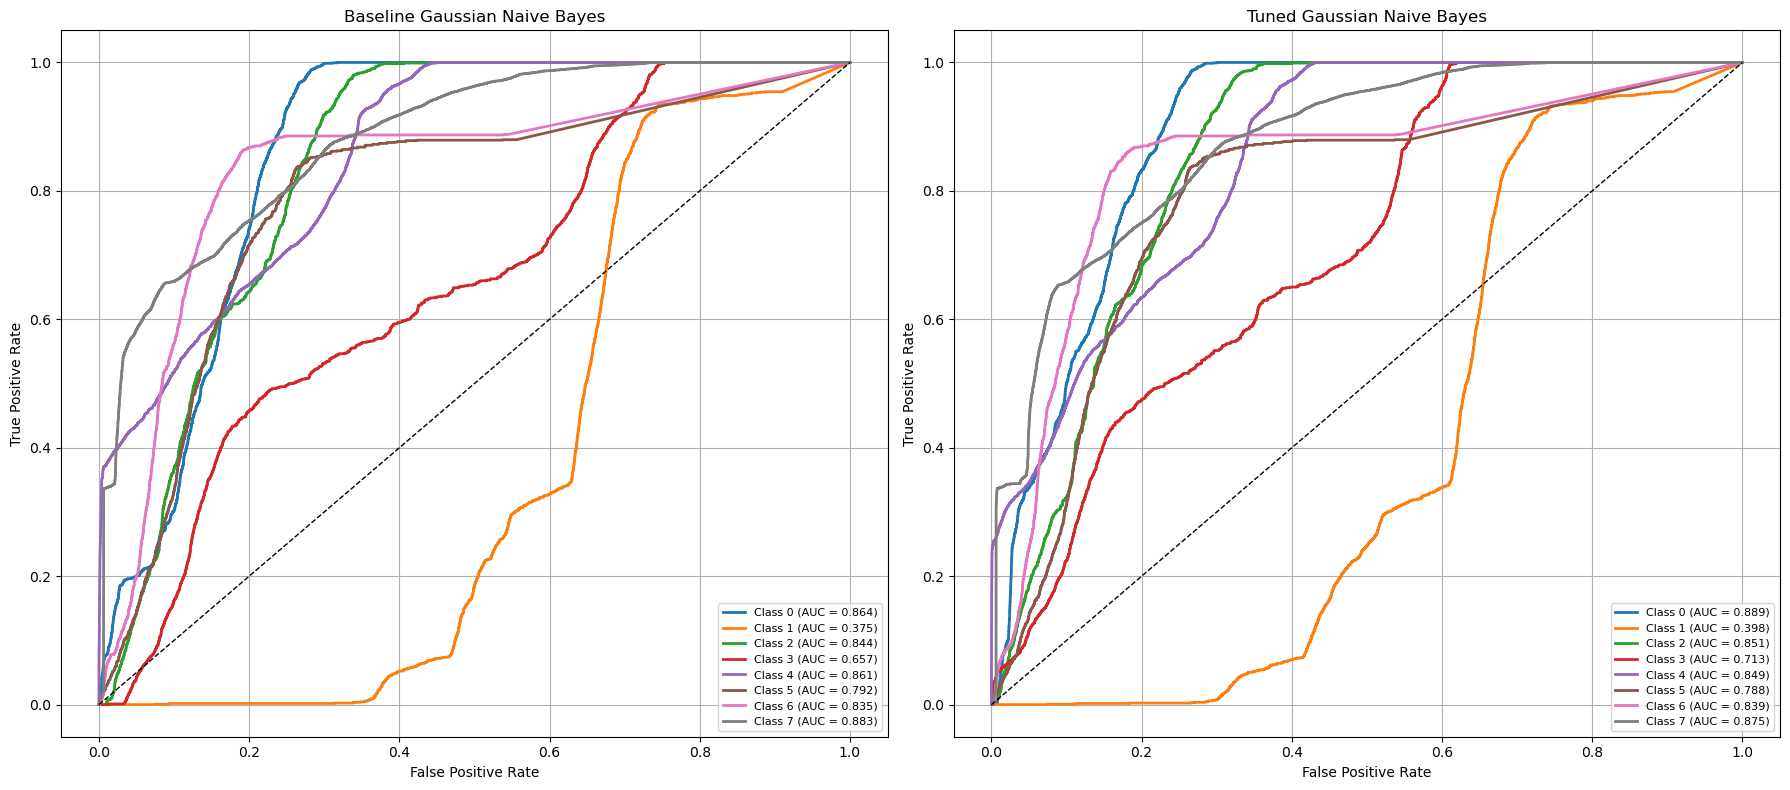

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Classes
classes = np.unique(y_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = gnb.predict_proba(X_test)
tuned_prob = best_gnb.predict_proba(X_test)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ---------------------------------------------------
# Baseline Gaussian Naive Bayes
# ---------------------------------------------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], baseline_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title("Baseline Gaussian Naive Bayes")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)

# ---------------------------------------------------
# Tuned Gaussian Naive Bayes
# ---------------------------------------------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], tuned_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Tuned Gaussian Naive Bayes")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

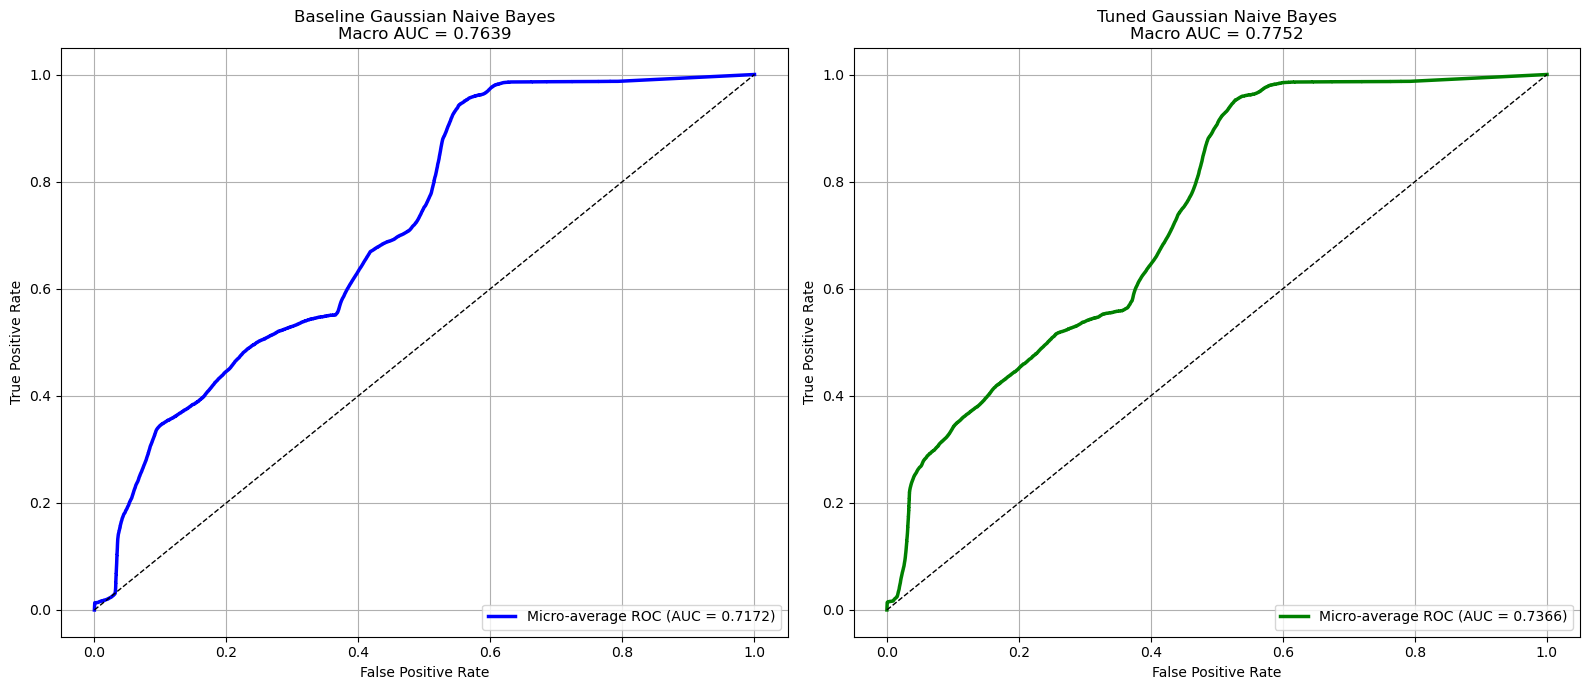

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Classes
classes = np.unique(y_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = gnb.predict_proba(X_test)
tuned_prob = best_gnb.predict_proba(X_test)

# --------------------------------------------------
# Baseline Gaussian Naive Bayes
# --------------------------------------------------
fpr_base, tpr_base, _ = roc_curve(
    y_test_bin.ravel(),
    baseline_prob.ravel()
)

micro_auc_base = auc(fpr_base, tpr_base)

macro_auc_base = roc_auc_score(
    y_test_bin,
    baseline_prob,
    average='macro',
    multi_class='ovr'
)

# --------------------------------------------------
# Tuned Gaussian Naive Bayes
# --------------------------------------------------
fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test_bin.ravel(),
    tuned_prob.ravel()
)

micro_auc_tuned = auc(fpr_tuned, tpr_tuned)

macro_auc_tuned = roc_auc_score(
    y_test_bin,
    tuned_prob,
    average='macro',
    multi_class='ovr'
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Baseline
axes[0].plot(
    fpr_base,
    tpr_base,
    color='blue',
    linewidth=2.5,
    label=f"Micro-average ROC (AUC = {micro_auc_base:.4f})"
)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)

axes[0].set_title(
    f"Baseline Gaussian Naive Bayes\nMacro AUC = {macro_auc_base:.4f}"
)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Tuned
axes[1].plot(
    fpr_tuned,
    tpr_tuned,
    color='green',
    linewidth=2.5,
    label=f"Micro-average ROC (AUC = {micro_auc_tuned:.4f})"
)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)

axes[1].set_title(
    f"Tuned Gaussian Naive Bayes\nMacro AUC = {macro_auc_tuned:.4f}"
)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()